# Portion pipeline feasibility — latest run EDA

Exploratory analysis for the **1,000-recipe / seed 42** portion-pipeline feasibility run
(`scratch/EDA/portion_feasibility_1000/`). Loads the redesign artifacts:

- `amount_classification.parquet` — rules parse + resolution plan + selective line enrichment
- `line_enrichment_llm_calls.parquet` — enrichment LLM audit log
- `judge_matches_raw.parquet` — portion-aware fdc judge + judge-time gram resolution
- `run_manifest.json` — run metadata

**Kernel cwd:** `Capstone/` or `scratch/EDA/`.

Set `REBUILD = True` in the build cell to refresh the merged parquet cache.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def resolve_capstone_root() -> Path:
    cwd = Path.cwd()
    for candidate in (cwd, cwd.parent, cwd.parent.parent):
        if (candidate / "scripts" / "db.py").is_file():
            return candidate
    raise FileNotFoundError("Run with kernel cwd = Capstone/ or scratch/EDA/")


ROOT = resolve_capstone_root()
FEAS_DIR = ROOT / "scratch" / "EDA" / "portion_feasibility_1000"
CACHE_PATH = FEAS_DIR / "portion_feasibility_eda.parquet"

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 220)

print(f"Capstone root: {ROOT}")
print(f"Feasibility dir: {FEAS_DIR}")

Capstone root: /Users/danielcosta/Berkeley/Capstone
Feasibility dir: /Users/danielcosta/Berkeley/Capstone/scratch/EDA/portion_feasibility_1000


## Build merged `eda_df`

Join amount classification with judge output on `(recipe_id, ingredient_idx, ingredient)`.

In [2]:
REBUILD = not CACHE_PATH.is_file()

JUDGE_COLS = [
    "llm_fdc_id", "llm_description", "llm_certainty", "llm_rationale", "llm_error",
    "llm_abstained", "llm_agrees_with_staged", "matched_portion_id",
    "llm_pick_has_volume_portion", "llm_pick_has_count_portion",
    "staged_fdc_id", "staged_description", "retrieval_tier", "portion_filter_kind",
    "grams", "grams_status", "grams_method", "pipeline_path",
    "prompt_tokens", "completion_tokens", "total_tokens", "price_estimate_usd",
    "staged_top1_in_llm_candidates", "staged_top1_in_top10",
]

AMOUNT_COLS = [
    "quantity", "quantity_max", "unit", "unit_raw", "name", "size", "preparation",
    "parse_status", "amount_kind", "amount_kind_final", "amount_kind_source",
    "needs_portion", "resolution_paths", "plan_flags", "enrichment_source",
    "line_enrichment_certainty", "line_enrichment_rationale",
]


def _flags_to_str(flags) -> str:
    if flags is None or (isinstance(flags, float) and pd.isna(flags)):
        return ""
    if hasattr(flags, "tolist"):
        flags = flags.tolist()
    if not flags:
        return ""
    return "|".join(str(f) for f in flags)


def _paths_to_str(paths) -> str:
    if paths is None or (isinstance(paths, float) and pd.isna(paths)):
        return ""
    if hasattr(paths, "tolist"):
        paths = paths.tolist()
    if not paths:
        return ""
    return "→".join(str(p) for p in paths)


def _resolution_bucket(row) -> str:
    status = row.get("grams_status")
    kind = row.get("amount_kind_final")
    has_fdc = pd.notna(row.get("llm_fdc_id"))

    if status in {
        "ok_volume_portion", "ok_count_portion", "ok_embedded_mass",
        "unresolvable_serving_only", "ambiguous_accepted", "vague_amount",
        "compound_skipped",
    }:
        return str(status)
    if not has_fdc:
        return "missing_fdc"
    if status == "no_portion":
        if kind == "volume" and row.get("llm_pick_has_volume_portion"):
            return "no_portion_fdc_has_volume_rows"
        if kind == "count" and row.get("llm_pick_has_count_portion"):
            return "no_portion_fdc_has_count_rows"
        if kind == "volume":
            return "no_portion_fdc_lacks_volume_rows"
        if kind == "count":
            return "no_portion_fdc_lacks_count_rows"
        return "no_portion"
    return str(status) if status is not None else "unknown"


def build_eda_df(*, rebuild: bool = False) -> pd.DataFrame:
    if not rebuild and CACHE_PATH.is_file():
        df = pd.read_parquet(CACHE_PATH)
        print(f"Loaded cached eda_df ({len(df):,} rows) → {CACHE_PATH}")
        return df

    manifest_path = FEAS_DIR / "run_manifest.json"
    manifest = json.loads(manifest_path.read_text()) if manifest_path.is_file() else {}

    amount = pd.read_parquet(FEAS_DIR / "amount_classification.parquet")
    judge = pd.read_parquet(FEAS_DIR / "judge_matches_raw.parquet")

    judge_keep = ["recipe_id", "ingredient_idx", "ingredient"] + [
        c for c in JUDGE_COLS if c in judge.columns
    ]
    amount_keep = ["recipe_id", "ingredient_idx", "ingredient"] + [
        c for c in AMOUNT_COLS if c in amount.columns
    ]

    df = amount[amount_keep].merge(
        judge[judge_keep],
        on=["recipe_id", "ingredient_idx", "ingredient"],
        how="inner",
    )

    df["plan_flags_str"] = [_flags_to_str(f) for f in df["plan_flags"]]
    df["resolution_paths_str"] = [_paths_to_str(p) for p in df["resolution_paths"]]
    df["has_fdc"] = df["llm_fdc_id"].notna()
    df["has_grams"] = df["grams"].notna()
    df["resolved_both"] = df["has_fdc"] & df["has_grams"]
    df["resolution_bucket"] = [_resolution_bucket(r) for r in df.to_dict(orient="records")]
    df["run_n_recipes"] = manifest.get("n_recipes")
    df["run_seed"] = manifest.get("seed")
    df["run_model"] = manifest.get("model")

    df.to_parquet(CACHE_PATH, index=False)
    print(f"Built eda_df ({len(df):,} rows) → {CACHE_PATH}")
    return df


eda_df = build_eda_df(rebuild=REBUILD)
print(f"Columns: {len(eda_df.columns)}")

Loaded cached eda_df (8,754 rows) → /Users/danielcosta/Berkeley/Capstone/scratch/EDA/portion_feasibility_1000/portion_feasibility_eda.parquet
Columns: 53


## Headline resolution rates

In [3]:
def _rate(mask: pd.Series, denom: int) -> float:
    return round(float(mask.sum()) / max(denom, 1), 4)


n = len(eda_df)
has_fdc = eda_df["has_fdc"]
has_grams = eda_df["has_grams"]
both = eda_df["resolved_both"]
needs = eda_df[eda_df["needs_portion"].fillna(False)]

summary = pd.DataFrame([
    {"scope": "all lines", "n": n,
     "fdc_rate": _rate(has_fdc, n), "gram_rate": _rate(has_grams, n),
     "fdc_and_gram_rate": _rate(both, n)},
    {"scope": "needs_portion", "n": len(needs),
     "fdc_rate": _rate(needs["has_fdc"], len(needs)),
     "gram_rate": _rate(needs["has_grams"], len(needs)),
     "fdc_and_gram_rate": _rate(needs["resolved_both"], len(needs))},
])

by_kind_rows = []
for kind in ["volume", "count", "mass", "unknown"]:
    sub = eda_df[eda_df["amount_kind_final"] == kind]
    if len(sub) == 0:
        continue
    by_kind_rows.append({
        "amount_kind_final": kind,
        "n": len(sub),
        "fdc_rate": _rate(sub["has_fdc"], len(sub)),
        "gram_rate": _rate(sub["has_grams"], len(sub)),
        "fdc_and_gram_rate": _rate(sub["resolved_both"], len(sub)),
    })
by_kind = pd.DataFrame(by_kind_rows)

display(summary)
display(by_kind)

,scope,n,fdc_rate,gram_rate,fdc_and_gram_rate
0,all lines,8754,0.9440,0.5870,0.5870
1,needs_portion,7466,0.9458,0.6118,0.6118


,amount_kind_final,n,fdc_rate,gram_rate,fdc_and_gram_rate
0,volume,4909,0.9550,0.7065,0.7065
1,count,2242,0.9282,0.3626,0.3626
2,mass,963,0.9045,0.8910,0.8910
3,unknown,640,0.9750,0.0000,0.0000


## Amount classification & resolution plan

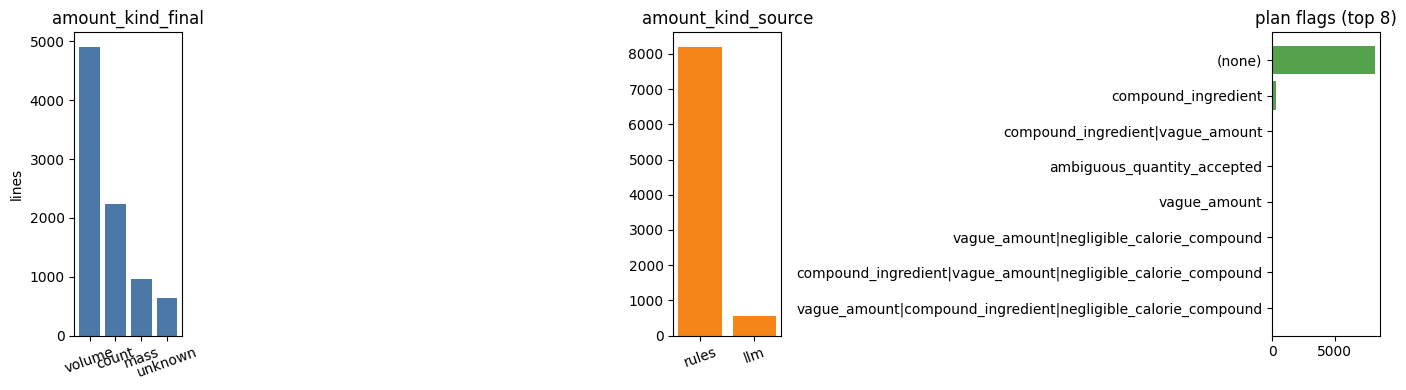

,n
resolution_paths_str,
explicit_volume,4858
count_portion,2022
,640
explicit_mass,573
parenthetical_mass_override→count_portion,281
count_portion→embedded_mass,123
count_portion→explicit_mass,58
count_portion→parenthetical_mass_override,36
explicit_mass→embedded_mass,30


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

kind_counts = eda_df["amount_kind_final"].value_counts()
axes[0].bar(kind_counts.index.astype(str), kind_counts.values, color="#4C78A8")
axes[0].set_title("amount_kind_final")
axes[0].set_ylabel("lines")
axes[0].tick_params(axis="x", rotation=20)

src_counts = eda_df["amount_kind_source"].value_counts()
axes[1].bar(src_counts.index.astype(str), src_counts.values, color="#F58518")
axes[1].set_title("amount_kind_source")
axes[1].tick_params(axis="x", rotation=20)

flag_series = eda_df["plan_flags_str"].replace("", "(none)")
flag_top = flag_series.value_counts().head(8)
axes[2].barh(flag_top.index.astype(str), flag_top.values, color="#54A24B")
axes[2].set_title("plan flags (top 8)")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

display(eda_df["resolution_paths_str"].value_counts().head(12).to_frame("n"))

## Gram resolution outcomes

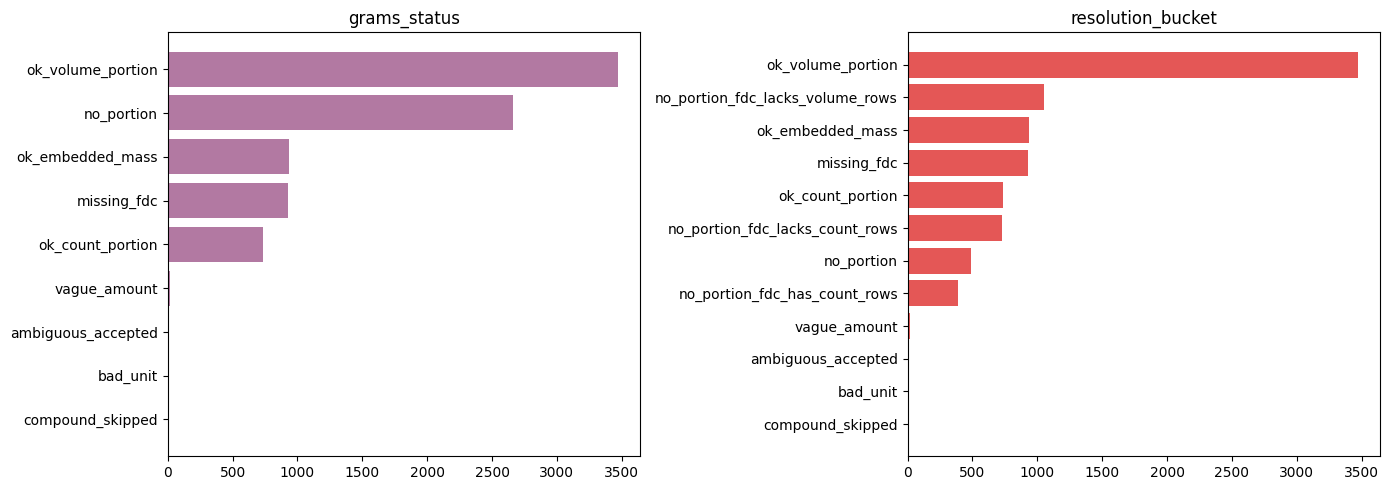

resolution_bucket,ambiguous_accepted,bad_unit,compound_skipped,missing_fdc,no_portion,no_portion_fdc_has_count_rows,no_portion_fdc_lacks_count_rows,no_portion_fdc_lacks_volume_rows,ok_count_portion,ok_embedded_mass,ok_volume_portion,vague_amount
amount_kind_final,,,,,,,,,,,,
count,7,1,2,287,0,391,727,0,737,74,0,16
mass,0,0,0,104,1,0,0,0,0,858,0,0
unknown,0,0,0,149,491,0,0,0,0,0,0,0
volume,0,4,0,388,0,0,0,1049,0,0,3468,0


In [5]:
status_counts = eda_df["grams_status"].value_counts()
bucket_counts = eda_df["resolution_bucket"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(status_counts.index.astype(str), status_counts.values, color="#B279A2")
axes[0].set_title("grams_status")
axes[0].invert_yaxis()

axes[1].barh(bucket_counts.index.astype(str), bucket_counts.values, color="#E45756")
axes[1].set_title("resolution_bucket")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

pivot = pd.crosstab(eda_df["amount_kind_final"], eda_df["resolution_bucket"])
display(pivot)

## LLM usage & cost

In [6]:
enrich_path = FEAS_DIR / "line_enrichment_llm_calls.parquet"
enrich_df = pd.read_parquet(enrich_path) if enrich_path.is_file() else pd.DataFrame()

judge_calls = len(eda_df)
judge_cost = float(eda_df["price_estimate_usd"].sum()) if "price_estimate_usd" in eda_df.columns else 0.0
judge_tokens = int(eda_df["total_tokens"].sum()) if "total_tokens" in eda_df.columns else 0

enrich_calls = len(enrich_df)
enrich_cost = float(enrich_df["price_estimate_usd"].sum()) if len(enrich_df) else 0.0
enrich_lines = int((eda_df["enrichment_source"] == "llm").sum()) if "enrichment_source" in eda_df.columns else 0

llm_summary = pd.DataFrame([
    {"phase": "line enrichment", "api_calls": enrich_calls, "lines_touched": enrich_lines,
     "cost_usd": round(enrich_cost, 4)},
    {"phase": "fdc judge", "api_calls": judge_calls, "lines_touched": judge_calls,
     "cost_usd": round(judge_cost, 4)},
    {"phase": "total", "api_calls": enrich_calls + judge_calls,
     "lines_touched": len(eda_df),
     "cost_usd": round(enrich_cost + judge_cost, 4)},
])
display(llm_summary)
print(f"Judge tokens: {judge_tokens:,}")
print(f"Avg judge calls per line: 1.0")
print(f"Avg enrichment calls per line (deduped): {enrich_calls / max(len(eda_df), 1):.3f}")

,phase,api_calls,lines_touched,cost_usd
0,line enrichment,474,551,0.0698
1,fdc judge,8754,8754,1.5229
2,total,9228,8754,1.5927


Judge tokens: 9,230,653
Avg judge calls per line: 1.0
Avg enrichment calls per line (deduped): 0.054


## Judge quality & retrieval

,metric,n,rate
0,llm_abstained,487,0.0556
1,llm_error,3,0.0003
2,llm_agrees_with_staged,2954,0.3374
3,matched_portion_id set,154,0.0176
4,staged_top1_in_llm_candidates,7626,0.8711


,n
retrieval_tier,
portion_ranked,7532
mass_in_text,1222


,n
portion_filter_kind,
volume,4886
count,2012


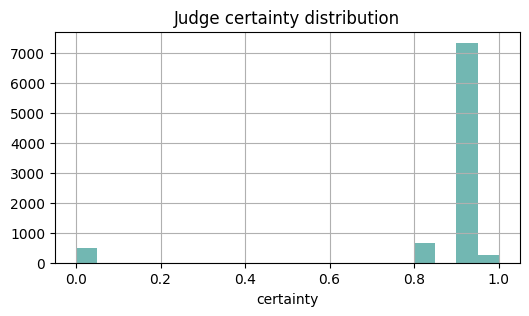

In [7]:
judge_quality = pd.DataFrame({
    "metric": [
        "llm_abstained", "llm_error", "llm_agrees_with_staged",
        "matched_portion_id set", "staged_top1_in_llm_candidates",
    ],
    "n": [
        int(eda_df["llm_abstained"].fillna(False).sum()) if "llm_abstained" in eda_df.columns else 0,
        int(eda_df["llm_error"].notna().sum()) if "llm_error" in eda_df.columns else 0,
        int(eda_df["llm_agrees_with_staged"].fillna(False).sum()) if "llm_agrees_with_staged" in eda_df.columns else 0,
        int(eda_df["matched_portion_id"].notna().sum()) if "matched_portion_id" in eda_df.columns else 0,
        int(eda_df["staged_top1_in_llm_candidates"].fillna(False).sum()) if "staged_top1_in_llm_candidates" in eda_df.columns else 0,
    ],
})
judge_quality["rate"] = (judge_quality["n"] / len(eda_df)).round(4)
display(judge_quality)

if "retrieval_tier" in eda_df.columns:
    display(eda_df["retrieval_tier"].value_counts().to_frame("n"))
if "portion_filter_kind" in eda_df.columns:
    display(eda_df["portion_filter_kind"].value_counts().to_frame("n"))

if "llm_certainty" in eda_df.columns:
    eda_df["llm_certainty"].dropna().hist(bins=20, figsize=(6, 3), color="#72B7B2")
    plt.title("Judge certainty distribution")
    plt.xlabel("certainty")
    plt.show()

## Explore / filter lines

Edit the filters below and re-run to inspect subsets.

In [8]:
FILTER_AMOUNT_KIND: str | None = None       # e.g. "count", "volume"
FILTER_RESOLUTION_BUCKET: str | None = None  # e.g. "no_portion_fdc_lacks_count_rows"
FILTER_GRAMS_STATUS: str | None = None       # e.g. "no_portion"
FILTER_NEEDS_PORTION: bool | None = None
FILTER_HAS_FDC: bool | None = None
FILTER_HAS_GRAMS: bool | None = None
FILTER_INGREDIENT_CONTAINS: str | None = None
MAX_ROWS = 40

DISPLAY_COLS = [
    "recipe_id", "ingredient_idx", "ingredient", "quantity", "unit", "name",
    "amount_kind_final", "amount_kind_source", "needs_portion",
    "resolution_paths_str", "plan_flags_str", "resolution_bucket", "grams_status",
    "llm_fdc_id", "llm_description", "matched_portion_id",
    "llm_pick_has_volume_portion", "llm_pick_has_count_portion",
    "grams", "grams_method", "pipeline_path",
    "llm_certainty", "llm_rationale", "llm_error",
    "retrieval_tier", "portion_filter_kind", "llm_agrees_with_staged",
]
DISPLAY_COLS = [c for c in DISPLAY_COLS if c in eda_df.columns]

view = eda_df.copy()
if FILTER_AMOUNT_KIND:
    view = view[view["amount_kind_final"] == FILTER_AMOUNT_KIND]
if FILTER_RESOLUTION_BUCKET:
    view = view[view["resolution_bucket"] == FILTER_RESOLUTION_BUCKET]
if FILTER_GRAMS_STATUS:
    view = view[view["grams_status"] == FILTER_GRAMS_STATUS]
if FILTER_NEEDS_PORTION is not None:
    view = view[view["needs_portion"].fillna(False) == FILTER_NEEDS_PORTION]
if FILTER_HAS_FDC is not None:
    view = view[view["has_fdc"] == FILTER_HAS_FDC]
if FILTER_HAS_GRAMS is not None:
    view = view[view["has_grams"] == FILTER_HAS_GRAMS]
if FILTER_INGREDIENT_CONTAINS:
    needle = FILTER_INGREDIENT_CONTAINS.lower()
    view = view[view["ingredient"].str.lower().str.contains(needle, na=False)]

print(f"Filtered rows: {len(view):,} / {len(eda_df):,}")
if len(view):
    display(view[DISPLAY_COLS].head(MAX_ROWS))
else:
    print("No rows match filters.")

Filtered rows: 8,754 / 8,754


,recipe_id,ingredient_idx,ingredient,quantity,unit,name,amount_kind_final,amount_kind_source,needs_portion,resolution_paths_str,...,llm_pick_has_count_portion,grams,grams_method,pipeline_path,llm_certainty,llm_rationale,llm_error,retrieval_tier,portion_filter_kind,llm_agrees_with_staged
0,1702,0,"1 bag (1 1/2 lb.) refrigerated, ready-to-cook red potatoes",1.00,each,"bag (1 1/2 lb.) refrigerated, ready-to-cook red potatoes",mass,rules,True,parenthetical_mass_override→count_portion,...,False,680.3886,mass:1.5 pound→g,mass→mass_in_text→llm→fdc=1115891→ok_embedded_mass,0.90,"Best match for red potatoes, despite no specific portion fit.",None,mass_in_text,None,True
1,1702,1,1/4 c. mayonnaise,0.25,cup,mayonnaise,volume,rules,True,explicit_volume,...,False,60.0000,volume:0.25 cup via portion#81777 (1.0 cup=240.0g),volume→portion_ranked→llm→fdc=167695→ok_volume_portion,0.80,Tofu mayonnaise matches best with a cup portion.,None,portion_ranked,volume,False
2,1702,2,1/4 c. chopped kosher dill pickles,0.25,cup,kosher dill pickles,volume,rules,True,explicit_volume,...,False,NaN,no fdc_id,volume→portion_ranked→llm→abstain→missing_fdc,0.00,No candidates match the volume portion for chopped kosher dill pickles.,None,portion_ranked,volume,False
3,1702,3,2 Tbsp. finely chopped shallot,2.00,tablespoon,finely shallot,volume,rules,True,explicit_volume,...,False,20.0000,volume:2.0 tablespoon via portion#86767 (1.0 tablespoon=10.0g),volume→portion_ranked→llm→fdc=170499→ok_volume_portion,0.90,Raw shallots match best with the ingredient description.,None,portion_ranked,volume,True
4,1702,4,1 Tbsp white wine vinegar,1.00,tablespoon,white wine vinegar,volume,rules,True,explicit_volume,...,False,NaN,no volume portion for fdc_id=411479,volume→portion_ranked→llm→fdc=411479→no_portion,0.90,Best match for white wine vinegar despite no portion lines.,None,portion_ranked,volume,True
5,1702,5,1/2 Tsp sugar,0.50,teaspoon,sugar,volume,rules,True,explicit_volume,...,False,2.0000,volume:0.5 teaspoon via portion#121732 (1.0 teaspoon=4.0g),volume→portion_ranked→llm→fdc=334247→ok_volume_portion,0.90,Granulated sugar matches best with the recipe's sugar type.,None,portion_ranked,volume,False
6,1702,6,1/2 Tsp salt,0.50,teaspoon,salt,volume,rules,True,explicit_volume,...,True,3.0000,volume:0.5 teaspoon via portion#92594 (1.0 teaspoon=6.0g),volume→portion_ranked→llm→fdc=173468→ok_volume_portion,0.90,Best match for table salt with a relevant portion.,None,portion_ranked,volume,False
7,1702,7,1 Tsp olive oil,1.00,teaspoon,olive oil,volume,rules,True,explicit_volume,...,False,4.5000,volume:1.0 teaspoon via portion#88669 (1.0 teaspoon=4.5g),volume→portion_ranked→llm→fdc=171413→ok_volume_portion,0.80,Best match for olive oil with teaspoon portion available.,None,portion_ranked,volume,False
8,1702,8,"1 cup frozen whole-kernel corn, partially thawed",1.00,cup,"whole-kernel corn, partially thawed",volume,rules,True,explicit_volume,...,False,141.0000,volume:1.0 cup via portion#84454 (1.0 cup=141.0g),volume→portion_ranked→llm→fdc=169217→ok_volume_portion,0.90,Best match for frozen whole-kernel corn with a fitting portion.,None,portion_ranked,volume,True
9,2398,0,1 stick margarine,1.00,stick,margarine,count,rules,True,count_portion,...,False,NaN,no resolution path succeeded,count→portion_ranked→llm→fdc=392340→no_portion,0.90,Margarine is the best match for the ingredient.,None,portion_ranked,count,True


In [11]:
view[view['grams_status'] == 'no_portion'].to_csv('no_portion_lines_v2.csv', index=False)

## Line enrichment audit (optional)

Inspect enrichment LLM calls for compound / vague / ambiguous lines.

In [ ]:
if enrich_df.empty:
    print("No line_enrichment_llm_calls.parquet found.")
else:
    enrich_display = enrich_df.sort_values("price_estimate_usd", ascending=False)
    cols = [c for c in [
        "ingredient_raw", "certainty", "rationale", "error",
        "prompt_tokens", "completion_tokens", "price_estimate_usd",
    ] if c in enrich_display.columns]
    display(enrich_display[cols].head(20))
    if enrich_display["error"].notna().any():
        print("Enrichment errors:", int(enrich_display["error"].notna().sum()))